In [1]:
!pip install -q tensorflow opencv-python scikit-learn seaborn

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/Dataset_BUSI_with_GT"

classes = ["normal", "benign", "malignant"]

image_size = 224

X = []
y = []

In [5]:
for label, category in enumerate(classes):
    folder = os.path.join(dataset_path, category)

    for file in os.listdir(folder):

        if "mask" in file:
            continue

        img_path = os.path.join(folder, file)

        img = cv2.imread(img_path)
        img = cv2.resize(img, (image_size, image_size))
        img = img / 255.0

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Total images:", len(X))

Total images: 780


In [6]:
class_counts = pd.Series(y).value_counts()

class_names = ["Normal", "Benign", "Malignant"]

for i, count in enumerate(class_counts):
    print(class_names[i], ":", count)

Normal : 437
Benign : 210
Malignant : 133


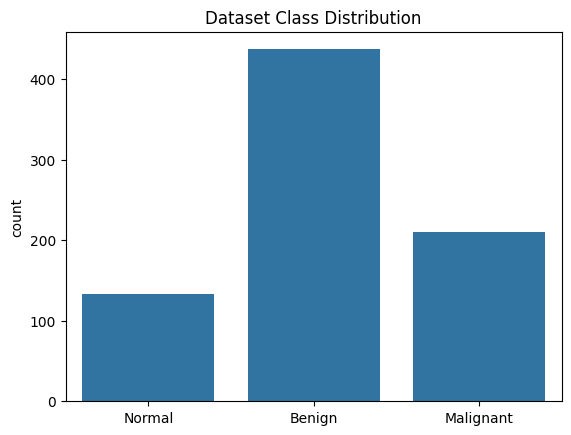

In [7]:
sns.countplot(x=y)
plt.xticks([0,1,2], class_names)
plt.title("Dataset Class Distribution")
plt.show()

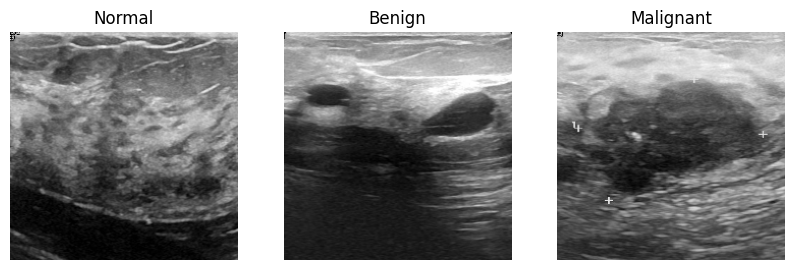

In [8]:
plt.figure(figsize=(10,4))

for i in range(3):
    idx = np.where(y == i)[0][0]

    plt.subplot(1,3,i+1)
    plt.imshow(X[idx])
    plt.title(class_names[i])
    plt.axis("off")

plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 624
Testing samples: 156


In [10]:
y_train = to_categorical(y_train, 3)
y_test = to_categorical(y_test, 3)

In [11]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(3, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [12]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=12,
    batch_size=16
)

Epoch 1/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 50s 846ms/step - accuracy: 0.5775 - loss: 0.9485 - val_accuracy: 0.6984 - val_loss: 0.7226
Epoch 2/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.7023 - loss: 0.7063 - val_accuracy: 0.7619 - val_loss: 0.6424
Epoch 3/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7576 - loss: 0.5740 - val_accuracy: 0.7619 - val_loss: 0.5279
Epoch 4/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7843 - loss: 0.5171 - val_accuracy: 0.8254 - val_loss: 0.5262
Epoch 5/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8200 - loss: 0.4636 - val_accuracy: 0.7778 - val_loss: 0.4765
Epoch 6/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8235 - loss: 0.4156 - val_accuracy: 0.8095 - val_loss: 0.4468
Epoch 7/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8431 - loss: 0.4029 - val_accuracy: 0.8730 - val_loss: 0.4092
Epoch 8/12
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8449 - loss: 0.4167 - val_accuracy: 0.7778 

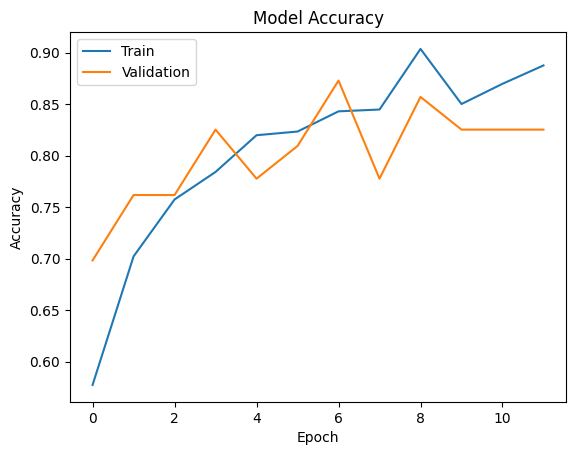

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

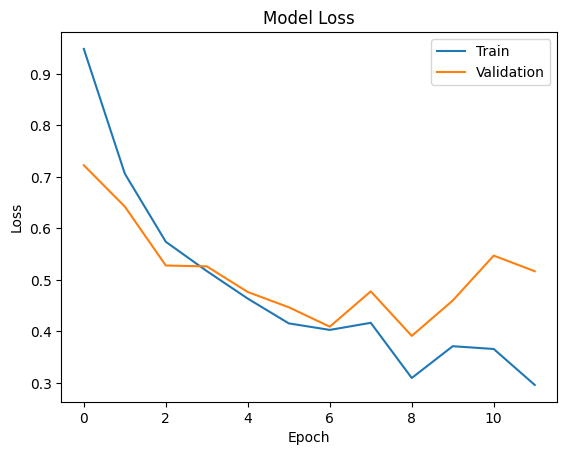

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.7628 - loss: 0.5802
Test Accuracy: 0.7628205418586731


In [17]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=class_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
              precision    recall  f1-score   support

      Normal       0.82      0.67      0.73        27
      Benign       0.82      0.79      0.81        87
   Malignant       0.64      0.76      0.70        42

    accuracy                           0.76       156
   macro avg       0.76      0.74      0.75       156
weighted avg       0.77      0.76      0.76       156



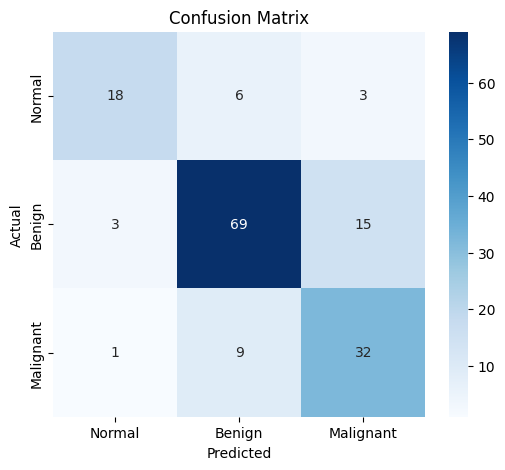

In [18]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


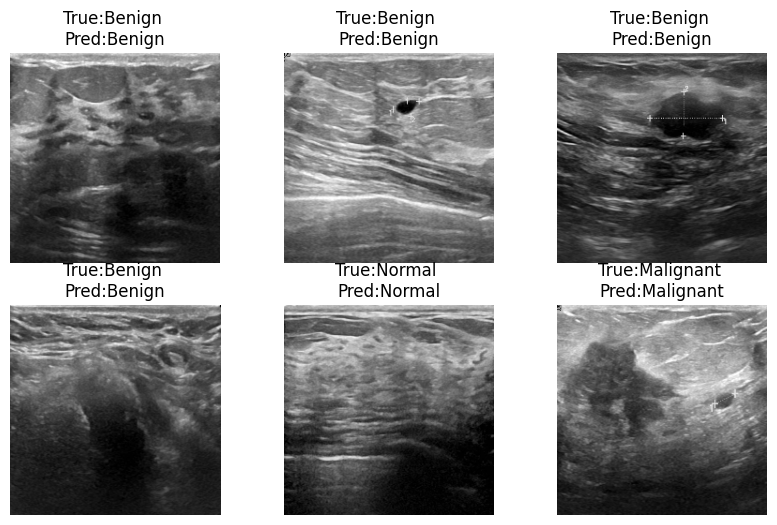

In [19]:
plt.figure(figsize=(10,6))

for i in range(6):

    idx = np.random.randint(0, len(X_test))

    img = X_test[idx]

    pred = model.predict(img.reshape(1,224,224,3))
    pred_class = np.argmax(pred)

    true_class = np.argmax(y_test[idx])

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"True:{class_names[true_class]} \nPred:{class_names[pred_class]}")
    plt.axis("off")

plt.show()